# Predição CNPq — TabPFN-3

## Por que TabPFN-3 aqui?
- **Zero tuning** — modelo pré-treinado, sem Optuna, sem espera
- **Suporta até 1M linhas e 200 features** (lançado maio/2026)
- **Roda em CPU** com performance competitiva
- Serve como **benchmark rápido** contra o CatBoost

## Limitação importante
TabPFN-3 suporta **máx 200 features**. Como usamos TF-IDF de texto,
vamos limitar `TFIDF_MAX=30` por coluna (60 total) + ~25 features base = ~85 features.
Cabe com folga.

## 1. Instalação e imports

In [70]:
%env TABPFN_ALLOW_CPU_LARGE_DATASET=1

env: TABPFN_ALLOW_CPU_LARGE_DATASET=1


In [71]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OrdinalEncoder

from tabpfn import TabPFNRegressor

# ── Configurações ──────────────────────────────────────────────────
ARQUIVO_PARQUET = 'dados/cnpqBolsasAuxilios_limpo.parquet'
TARGET          = 'valor_pago'
N_SAMPLE        = 10000
RANDOM_STATE    = 67
TFIDF_MAX       = 30   # 30 por coluna de texto → 60 total, cabe no limite de 200

print('Imports OK ✅')

Imports OK ✅


## 2. Carregamento e feature engineering

Mesmo pipeline do CatBoost v3 para comparação justa:
- `nivel_ordinal` mapeado à mão
- Texto via TF-IDF pré-processado
- Categóricas via OrdinalEncoder (TabPFN aceita só numéricas)

In [72]:
print('Carregando...')
df_full = pd.read_parquet(ARQUIVO_PARQUET)
df = df_full.sample(n=min(N_SAMPLE, len(df_full)), random_state=RANDOM_STATE).copy()
print(f'Shape: {df.shape}')

if '_record_number' in df.columns:
    df = df.drop(columns=['_record_number'])

# Filtro p95
y_num = pd.to_numeric(df[TARGET], errors='coerce')
teto  = y_num.quantile(0.95)
df    = df[y_num <= teto].copy()
print(f'Teto p95: R$ {teto:,.2f} | Shape: {df.shape}')

Carregando...
Shape: (10000, 27)
Teto p95: R$ 35,000.00 | Shape: (9509, 26)


In [73]:
# ── Feature engineering (igual ao CatBoost v3) ────────────────────
NIVEL_MAP = {
    '1A': 9, '1B': 8, '1C': 7, '1D': 6,
    '2': 5, '2A': 5, '2B': 4,
    'DT-1A': 9, 'DT-1B': 8, 'DT-2': 5,
    'PDS': 6, 'PDJ': 6,
    'DO': 4, 'DS': 4, 'GD': 4, 'SWE': 4,
    'ME': 3, 'MS': 3,
    'IC': 2, 'ITI': 2, 'AT': 2,
    'B': 3, 'A': 2, 'C': 1,
}

def map_nivel(s):
    if pd.isna(s) or str(s).strip() in ('', 'nulo', 'nan'):
        return 0
    s = str(s).strip().upper()
    if s in NIVEL_MAP: return NIVEL_MAP[s]
    s2 = s.replace(' ', '')
    if s2 in NIVEL_MAP: return NIVEL_MAP[s2]
    m = re.search(r'(\d+[A-D]?)', s)
    if m and m.group(1) in NIVEL_MAP: return NIVEL_MAP[m.group(1)]
    return 0

df['nivel_ordinal']           = df['categoria_nivel'].apply(map_nivel)
df['ano_referencia']          = pd.to_numeric(df['ano_referencia'], errors='coerce').fillna(2020)
df['anos_desde_2000']         = df['ano_referencia'] - 2000
df['natureza_de_despesa_str'] = df['natureza_de_despesa'].fillna(-1).astype(int).astype(str)
df['titulo_do_projeto']       = df['titulo_do_projeto'].fillna('').astype(str)
df['palavra_chave']           = df['palavra_chave'].fillna('').astype(str)

print('Feature engineering OK ✅')

Feature engineering OK ✅


In [74]:
# ── Target ────────────────────────────────────────────────────────
y_num  = pd.to_numeric(df[TARGET], errors='coerce')
mask   = y_num.notna() & (y_num > 0)
df     = df.loc[mask].reset_index(drop=True)
y_raw  = y_num.loc[mask].values
y_log  = np.log1p(y_raw)
mask2  = np.isfinite(y_log)
df, y_raw, y_log = df.loc[mask2].reset_index(drop=True), y_raw[mask2], y_log[mask2]

# ── Definição de colunas ──────────────────────────────────────────
TEXT_COLS = ['titulo_do_projeto', 'palavra_chave']
CAT_COLS  = [
    'linha_de_fomento', 'modalidade', 'programa_cnpq',
    'grande_area', 'area', 'subarea',
    'instituicao_origem', 'sigla_uf_origem', 'pais_origem',
    'instituicao_destino', 'sigla_instituicao_destino',
    'sigla_instituicao_macro', 'cidade_destino',
    'sigla_uf_destino', 'regiao_destino', 'pais_destino',
    'uo', 'categoria', 'tipo_modalidade', 'natureza_de_despesa_str',
]
DROP_COLS = ['categoria_nivel'] + TEXT_COLS

CAT_COLS  = [c for c in CAT_COLS  if c in df.columns]
TEXT_COLS = [c for c in TEXT_COLS if c in df.columns]

X = df.drop(columns=[TARGET] + [c for c in DROP_COLS if c in df.columns])

# Preenche categóricas
for c in CAT_COLS:
    if c in X.columns:
        X[c] = X[c].fillna('MISSING').astype(str)

# Numéricas
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]
for c in NUM_COLS:
    X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)

# Split 70/15/15
idx = np.arange(len(X))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=RANDOM_STATE)
idx_valid, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=RANDOM_STATE)

print(f'Treino: {len(idx_train)} | Validação: {len(idx_valid)} | Teste: {len(idx_test)}')

Treino: 6647 | Validação: 1425 | Teste: 1425


## 3. Pré-processamento para TabPFN

TabPFN aceita **só numéricas**. Estratégia:
- Categóricas → `OrdinalEncoder` (fit só no treino)
- Texto → `TfidfVectorizer` com `max_features=30` (fit só no treino)
- Total de features controlado para ficar abaixo de 200

In [75]:
texts_train = {c: df.iloc[idx_train][c].values for c in TEXT_COLS}
texts_valid = {c: df.iloc[idx_valid][c].values for c in TEXT_COLS}
texts_test  = {c: df.iloc[idx_test][c].values  for c in TEXT_COLS}

X_train_base = X.iloc[idx_train].copy().reset_index(drop=True)
X_valid_base = X.iloc[idx_valid].copy().reset_index(drop=True)
X_test_base  = X.iloc[idx_test].copy().reset_index(drop=True)

# ── OrdinalEncoder para categóricas ──────────────────────────────
cat_cols_present = [c for c in CAT_COLS if c in X_train_base.columns]
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_base[cat_cols_present] = enc.fit_transform(X_train_base[cat_cols_present])
X_valid_base[cat_cols_present] = enc.transform(X_valid_base[cat_cols_present])
X_test_base[cat_cols_present]  = enc.transform(X_test_base[cat_cols_present])

# ── TF-IDF para texto ─────────────────────────────────────────────
tfidf_vecs = {}
tfidf_parts_train, tfidf_parts_valid, tfidf_parts_test = [], [], []

for col in TEXT_COLS:
    vec = TfidfVectorizer(
        max_features=TFIDF_MAX,
        ngram_range=(1, 2),
        min_df=3,
        sublinear_tf=True,
        strip_accents='unicode',
    )
    mat_tr = vec.fit_transform(texts_train[col]).toarray()
    mat_va = vec.transform(texts_valid[col]).toarray()
    mat_te = vec.transform(texts_test[col]).toarray()

    cols = [f'tfidf_{col}_{i}' for i in range(mat_tr.shape[1])]
    tfidf_parts_train.append(pd.DataFrame(mat_tr, columns=cols))
    tfidf_parts_valid.append(pd.DataFrame(mat_va, columns=cols))
    tfidf_parts_test.append(pd.DataFrame(mat_te, columns=cols))
    tfidf_vecs[col] = vec
    print(f'TF-IDF {col}: {mat_tr.shape[1]} features')

X_train = pd.concat([X_train_base] + tfidf_parts_train, axis=1)
X_valid = pd.concat([X_valid_base] + tfidf_parts_valid, axis=1)
X_test  = pd.concat([X_test_base]  + tfidf_parts_test,  axis=1)

y_train_log, y_valid_log, y_test_log = y_log[idx_train], y_log[idx_valid], y_log[idx_test]
y_train_raw, y_valid_raw, y_test_raw = y_raw[idx_train], y_raw[idx_valid], y_raw[idx_test]

print(f'\nShape final: {X_train.shape} features')
print(f'Limite TabPFN-3: 200 features — {"OK ✅" if X_train.shape[1] <= 200 else "⚠️ EXCEDE! Reduza TFIDF_MAX"}')

TF-IDF titulo_do_projeto: 30 features
TF-IDF palavra_chave: 30 features

Shape final: (6647, 85) features
Limite TabPFN-3: 200 features — OK ✅


## 4. Treino do TabPFN-3

**Sem Optuna, sem tuning** — o modelo é pré-treinado e faz inferência direta.
O `.fit()` é instantâneo; o tempo real é no `.predict()` (processa o contexto inteiro).

In [76]:
import time
import os
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"
model = TabPFNRegressor(
    n_estimators=64,        # ensemble interno — mais = melhor, mas mais lento
    device='cpu',
    random_state=RANDOM_STATE,
    ignore_pretraining_limits=False,  # respeita limite de 200 features
)

print('Treinando TabPFN-3 (fit é quase instantâneo)...')
t0 = time.time()
model.fit(X_train.values, y_train_log)
print(f'Fit: {time.time()-t0:.1f}s')

print('Predizendo no teste...')
t0 = time.time()
pred_log = model.predict(X_test.values)
print(f'Predict: {time.time()-t0:.1f}s')

pred_real = np.expm1(pred_log)

r2_log    = r2_score(y_test_log, pred_log)
rmse_log  = np.sqrt(mean_squared_error(y_test_log, pred_log))
r2_real   = r2_score(y_test_raw, pred_real)
mae_real  = mean_absolute_error(y_test_raw, pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_raw, pred_real))

print('\n' + '═'*50)
print('RESULTADO — TabPFN-3 (sem tuning)')
print('═'*50)
print(f'[Espaço log]')
print(f'  R²   = {r2_log:.4f}')
print(f'  RMSE = {rmse_log:.4f}')
print(f'\n[Espaço real (R$)]')
print(f'  R²   = {r2_real:.4f}  ← CatBoost baseline era 0.5757')
print(f'  MAE  = R$ {mae_real:,.2f}')
print(f'  RMSE = R$ {rmse_real:,.2f}')
print('═'*50)

Treinando TabPFN-3 (fit é quase instantâneo)...
Fit: 3.2s
Predizendo no teste...
Predict: 2627.8s

══════════════════════════════════════════════════
RESULTADO — TabPFN-3 (sem tuning)
══════════════════════════════════════════════════
[Espaço log]
  R²   = 0.7015
  RMSE = 0.7150

[Espaço real (R$)]
  R²   = 0.5885  ← CatBoost baseline era 0.5757
  MAE  = R$ 3,166.50
  RMSE = R$ 5,331.24
══════════════════════════════════════════════════


## 5. Ajustes se o resultado não satisfizer

Se o R² ficar abaixo do esperado, dois knobs simples:

In [77]:
# ── Opção A: mais estimadores (ensemble maior) ────────────────────
# Troque n_estimators=8 por 16 ou 32 no modelo acima.
# Cada dobrada aumenta ~20% no tempo de predict mas melhora R².

# ── Opção B: correção de viés pós-modelo ─────────────────────────
pred_log_valid = model.predict(X_valid.values)
bias = np.median(y_valid_log - pred_log_valid)
print(f'Viés mediano (log): {bias:.4f}')

if abs(bias) > 0.02:
    pred_log_corr  = pred_log + bias
    pred_real_corr = np.expm1(pred_log_corr)
    r2_corr  = r2_score(y_test_raw, pred_real_corr)
    mae_corr = mean_absolute_error(y_test_raw, pred_real_corr)
    print(f'\n[Com correção de viés]')
    print(f'  R²  = {r2_corr:.4f}  (antes: {r2_real:.4f})')
    print(f'  MAE = R$ {mae_corr:,.2f}  (antes: R$ {mae_real:,.2f})')
else:
    print('Viés pequeno — sem necessidade de correção.')

Viés mediano (log): 0.1037

[Com correção de viés]
  R²  = 0.6061  (antes: 0.5885)
  MAE = R$ 3,020.78  (antes: R$ 3,166.50)


## 6. Plots de diagnóstico

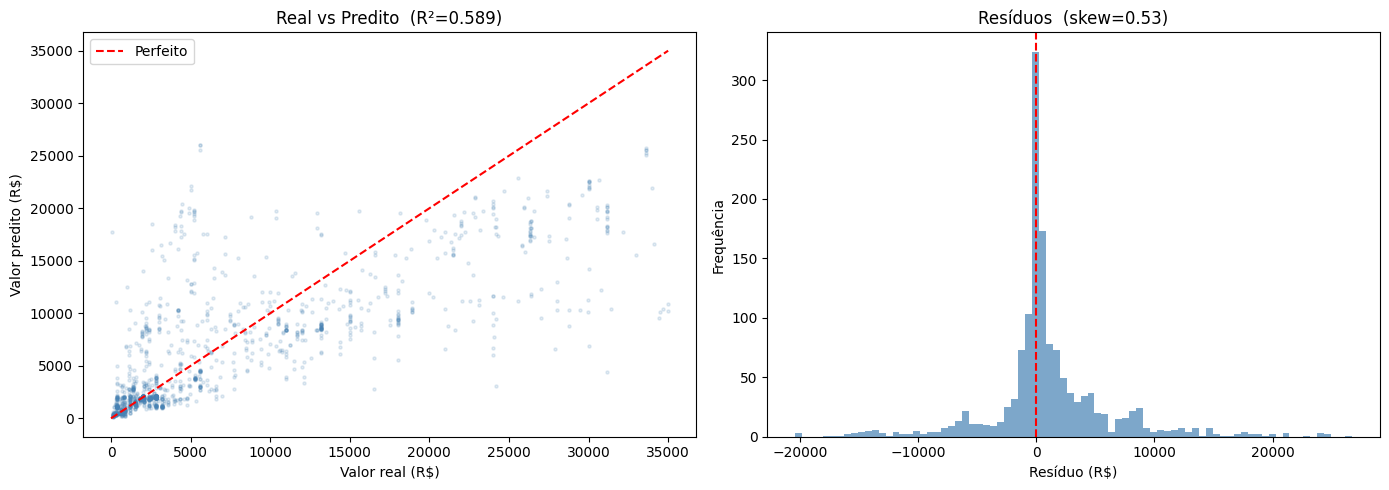

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test_raw, pred_real, alpha=0.15, s=5, color='steelblue')
lim = max(y_test_raw.max(), pred_real.max())
ax.plot([0, lim], [0, lim], 'r--', label='Perfeito')
ax.set_xlabel('Valor real (R$)')
ax.set_ylabel('Valor predito (R$)')
ax.set_title(f'Real vs Predito  (R²={r2_real:.3f})')
ax.legend()

ax = axes[1]
residuos = y_test_raw - pred_real
ax.hist(residuos, bins=80, color='steelblue', edgecolor='none', alpha=0.7)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Resíduo (R$)')
ax.set_ylabel('Frequência')
ax.set_title(f'Resíduos  (skew={pd.Series(residuos).skew():.2f})')

plt.tight_layout()
plt.savefig('tabpfn3_real_vs_predito.png', dpi=150)
plt.show()

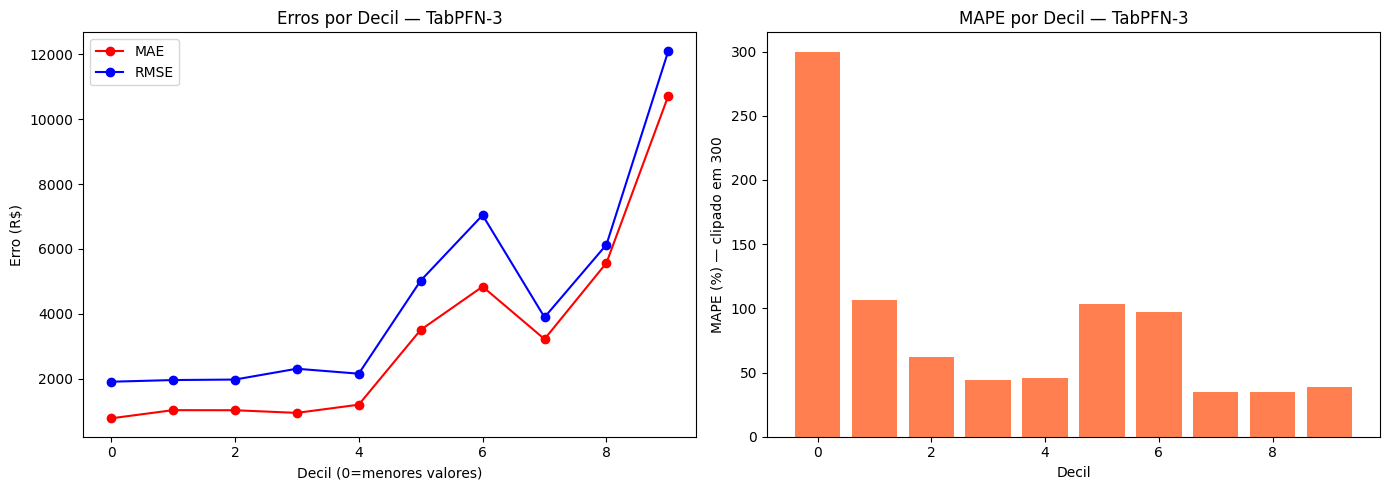

           MAE     RMSE   MAPE  real_med
decil                                   
0        774.1   1903.0  336.0     347.6
1       1026.2   1955.1  106.6     950.5
2       1024.1   1970.2   62.3    1603.6
3        942.4   2303.6   44.0    2048.2
4       1195.0   2151.3   45.8    2665.3
5       3502.5   5020.5  103.5    3400.2
6       4836.1   7040.8   97.1    5136.3
7       3217.3   3892.0   34.9    9548.1
8       5567.8   6130.1   34.6   16032.5
9      10727.1  12111.9   38.5   27343.4


In [79]:
df_eval = pd.DataFrame({
    'real':    y_test_raw,
    'predito': pred_real,
    'residuo': residuos,
    'abs_err': np.abs(residuos),
})
df_eval['decil'] = pd.qcut(df_eval['real'], 10, labels=False)

decil_metrics = df_eval.groupby('decil').agg(
    MAE      =('abs_err', 'mean'),
    RMSE     =('residuo', lambda x: np.sqrt((x**2).mean())),
    MAPE     =('abs_err', lambda x: (x / df_eval.loc[x.index, 'real'].clip(1)).mean() * 100),
    real_med =('real', 'mean'),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(decil_metrics.index, decil_metrics['MAE'],  marker='o', label='MAE',  color='red')
ax.plot(decil_metrics.index, decil_metrics['RMSE'], marker='o', label='RMSE', color='blue')
ax.set_xlabel('Decil (0=menores valores)')
ax.set_ylabel('Erro (R$)')
ax.set_title('Erros por Decil — TabPFN-3')
ax.legend()

ax = axes[1]
ax.bar(decil_metrics.index, decil_metrics['MAPE'].clip(upper=300), color='coral')
ax.set_xlabel('Decil')
ax.set_ylabel('MAPE (%) — clipado em 300')
ax.set_title('MAPE por Decil — TabPFN-3')

plt.tight_layout()
plt.savefig('tabpfn3_erro_decil.png', dpi=150)
plt.show()

print(decil_metrics.round(1).to_string())

## 7. Tabela comparativa

Preenche com os valores dos outros modelos para comparação direta.

In [80]:
# Preenche os valores dos outros modelos aqui
resultados = pd.DataFrame([
    {'Modelo': 'XGBoost v2 (baseline)',     'R² real': 0.597,  'MAE (R$)': None,     'Tuning': 'Optuna 80 trials'},
    {'Modelo': 'CatBoost v3 CPU baseline',  'R² real': 0.5757, 'MAE (R$)': 3263.95,  'Tuning': 'Nenhum'},
    {'Modelo': 'CatBoost v3 CPU final',     'R² real': 0.5530, 'MAE (R$)': 3351.53,  'Tuning': 'Optuna (10k amostras — ruim)'},
    {'Modelo': 'TabPFN-3 (este notebook)',  'R² real': r2_real, 'MAE (R$)': mae_real, 'Tuning': 'Zero'},
])

print(resultados.to_string(index=False))
print(f'\n→ TabPFN-3 ficou {"ACIMA" if r2_real > 0.597 else "ABAIXO"} do XGBoost v2 (R²=0.597)')
print(f'→ TabPFN-3 ficou {"ACIMA" if r2_real > 0.5757 else "ABAIXO"} do CatBoost baseline (R²=0.5757)')

                  Modelo  R² real    MAE (R$)                       Tuning
   XGBoost v2 (baseline) 0.597000         NaN             Optuna 80 trials
CatBoost v3 CPU baseline 0.575700 3263.950000                       Nenhum
   CatBoost v3 CPU final 0.553000 3351.530000 Optuna (10k amostras — ruim)
TabPFN-3 (este notebook) 0.588544 3166.497715                         Zero

→ TabPFN-3 ficou ABAIXO do XGBoost v2 (R²=0.597)
→ TabPFN-3 ficou ACIMA do CatBoost baseline (R²=0.5757)
